# Neliparametrisen logistisen annos-vastekäyrän sovittaminen PROC NLIN -proseduurilla

## Tiivistelmä

Tässä muistikirjassa sovitetaan neliparametrinen logistinen (4PL) annos-vastemalli synteettiseen solupohjaiseen potenssin biomääritykseen **PROC NLIN** -proseduurilla ja estimoidaan alempi ja ylempi asymptootti, EC50 (puolet maksimivasteesta tuottava tehollinen pitoisuus) sekä Hillin kulmakerroin. 4PL on lääkekehityksen suhteellisen potenssin määritysten työjuhtamalli, ja muistikirja käy läpi mallin määrittelyn, parametrien rajaamisen, konvergenssidiagnostiikan sekä sovitetun sigmoidin piirtämisen havaittujen pitoisuus-vastetietojen päälle.

## Tietolähteet

Muistikirja luo yhden synteettisen aineiston koodin sisällä; ulkoista tai verkosta haettua syötettä ei käytetä.

**`assay` — synteettinen solupohjainen potenssin biomääritys (24 riviä)**

| Muuttuja | Tyyppi | Kuvaus |
|----------|------|-------------|
| `lot` | num | Lääkeaine-erä (1-3); laimennussarjan kolme toistoajoa |
| `dose` | num | Yhdisteen pitoisuus (nmol/L) 8-pisteisessä sarjalaimennuksessa (0.1 – noin 1000) |
| `logdose` | num | `dose`-arvon 10-kantainen logaritmi, jota käytetään piirtämiseen tavanomaisella log-pitoisuusakselilla |
| `response` | num | Mitattu määrityssignaali (prosenttia maksimivasteesta), luotu todellisesta 4PL-käyrästä (pohja=5, huippu=100, EC50=25 nmol/L, Hillin kulmakerroin=1.2) sekä suhteellisesta Gaussin kohinasta |

Todelliset generoivat parametrit on kirjattu DATA-vaiheeseen, jotta NLINin palauttamat estimaatit voidaan varmentaa tunnettua totuutta vasten.

# Neliparametrisen logistisen annos-vastekäyrän sovittaminen

Lääkkeiden potenssi- ja bioaktiivisuusmäärityksissä yhdisteen pitoisuuden ja mitatun vasteen välinen suhde on tyypillisesti sigmoidinen log-pitoisuusasteikolla. **Neliparametrinen logistinen (4PL)** malli on vakiotyökalu tällaisten käyrien tiivistämiseen:

$$\text{response} = D + \frac{A - D}{1 + (\text{dose}/C)^{B}}$$

missä

- **A** = alempi asymptootti (vaste äärettömässä laimennuksessa / perustason signaali),
- **D** = ylempi asymptootti (maksimivaste kyllästävässä pitoisuudessa),
- **C** = **EC50**, pitoisuus, joka tuottaa puolet maksimivasteesta (käännepiste ja ensisijainen potenssin mittari),
- **B** = **Hillin kulmakerroin**, joka säätelee siirtymän jyrkkyyttä.

Malli on epälineaarinen parametriensa suhteen, joten sovitamme sen iteratiivisella pienimmän neliösumman menetelmällä `PROC NLIN` -proseduurilla. Alla simuloimme realistisen kahdeksanpisteisen laimennussarjan kolmena toistona, sovitamme 4PL-käyrän, rajaamme parametrit fysikaalisesti mielekkäille alueille, tarkastelemme konvergenssi- ja sovitusdiagnostiikkaa sekä piirrämme sovitetun käyrän tietojen päälle.

## Vaihe 1 — Simuloi solupohjainen potenssin biomääritys

Luomme synteettisen aineiston *tunnetusta* 4PL-käyrästä (pohja = 5, huippu = 100, EC50 = 25 nmol/L, Hillin kulmakerroin = 1.2), jotta NLINin palauttamat parametrit voidaan tarkistaa todellista arvoa vasten. Kolme erää saavat kukin saman kahdeksanpisteisen sarjalaimennuksen (jokainen askel 3.5-kertainen laimennus), johon on lisätty suhteellinen Gaussin mittauskohina. Kiinteä `streaminit`-siemen tekee simulaatiosta toistettavan.

In [1]:
TIEDOT assay;
    CALL streaminit(40521);

    /* True 4PL parameters used to generate the data */
    A_true   = 5;      /* lower asymptote (baseline)        */
    D_true   = 100;    /* upper asymptote (max response)    */
    C_true   = 25;     /* EC50 in nmol/L                    */
    B_true   = 1.2;    /* Hill slope                        */

    TEE lot = 1 ASTI 3;
        /* Eight-point serial dilution, 3.5-fold steps */
        dose = 0.30;
        TEE point = 1 ASTI 8;
            dose = dose * 3.5;

            /* Noise-free 4PL mean response */
            mu = D_true + (A_true - D_true) /
                 (1 + (dose / C_true) ** B_true);

            /* Proportional + additive Gaussian assay noise */
            response = mu * (1 + 0.04 * rand('NORMAL'))
                          + 1.5 * rand('NORMAL');

            logdose = log10(dose);
            TULOSTE;
        LOPPU;
    LOPPU;

    SÄILYTÄ lot dose logdose response;
    NIMIKE lot      = "Erä"
          dose     = "Annos (nmol/L)"
          logdose  = "log10(Annos)"
          response = "Vaste (% maksimista)";
SUORITA;

PROSEDUURI LAJITTELE TIEDOT=assay;
    MUKAAN dose lot;
SUORITA;


NOTE: DATA assay


NOTE: Wrote assay (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=assay

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from assay.
NOTE: Wrote assay (24 rows, 4 columns).
NOTE: PROC SORT statement used.


## Vaihe 2 — Visualisoi raa'at pitoisuus-vastetiedot

Ennen sovittamista piirrämme vasteen log10(dose):n suhteen vahvistaaksemme odotetun sigmoidisen muodon ja lukeaksemme karkeat aloitusarvot: käyrä pohjaa lähelle arvoa 5, tasaantuu lähelle arvoa 100, ja keskikohta (puolet maksimivasteesta) sijaitsee noin log10(25) ≈ 1.4 kohdalla.


NOTE: PROC SGPLOT data=assay

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


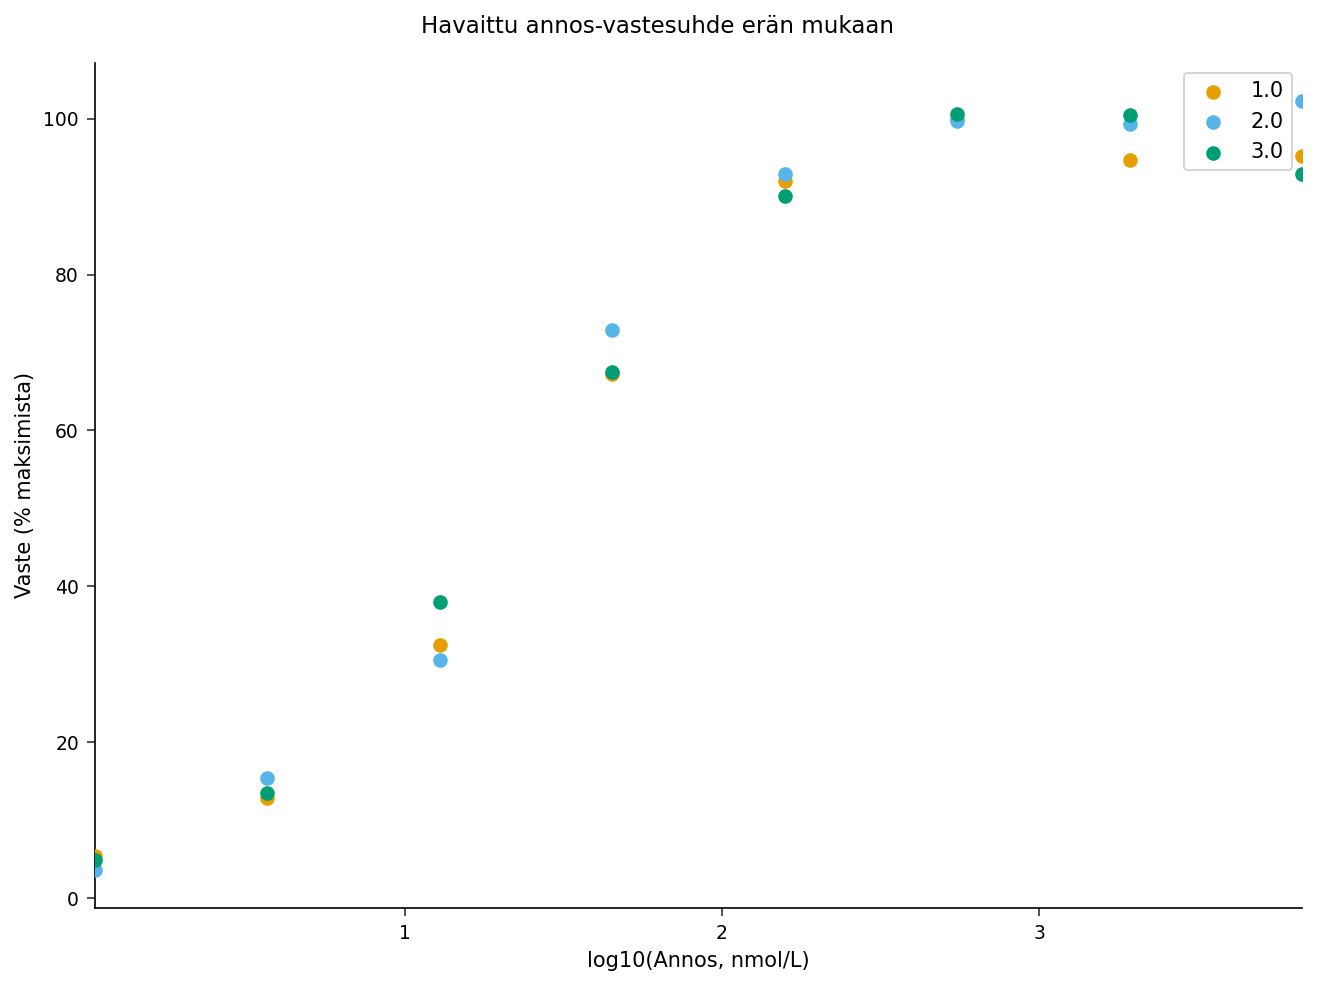

In [2]:
PROSEDUURI SGPLOT TIEDOT=assay;
    SCATTER x=logdose y=response / GROUP=lot
            MARKERATTRS=(SYMBOL=circlefilled);
    XAXIS LABEL='log10(Annos, nmol/L)';
    YAXIS LABEL='Vaste (% maksimista)';
    OTSIKKO 'Havaittu annos-vastesuhde erän mukaan';
SUORITA;
OTSIKKO;

## Vaihe 3 — Sovita 4PL-malli PROC NLIN -proseduurilla

Määrittelemme aloitusarvot `PARMS`-lauseella (hajontakuvion perusteella), määritämme 4PL-keskiarvon välituloksen sijoituslauseessa ja välitämme sen `MODEL`-lauseelle. Fysikaalisesti mielekkäät `BOUNDS`-rajat pitävät asymptootit järjestyksessä sekä EC50:n ja kulmakertoimen positiivisina, mikä vakauttaa Gauss-Newton-iteraatioita. `OUTPUT`-lause tallentaa ennustetut arvot, residuaalit ja luottamusrajat myöhempää diagnostiikkaa varten, ja `PLOTS=` pyytää sovitus- ja diagnostiikkapaneelit.

In [3]:
PROSEDUURI nlin TIEDOT=assay METHOD=marquardt PLOTS=(fitplot diagnostics);
    NIMIKE A = "Alaraja"
          D = "Yläraja"
          C = "EC50"
          B = "Kaltevuus";
    parms A=10 D=90 C=20 B=1;

    /* Keep parameters in physically sensible regions */
    bounds A >= 0, D <= 150, C > 0, B > 0;

    /* Four-parameter logistic mean response (inlined: Jenner PROC NLIN
       does not yet support referencing an intermediate programming-statement
       variable in the MODEL — see tests/400986 — so we inline the denominator) */
    MODEL response = D + (A - D) / (1 + (dose / C) ** B);

    TULOSTE out=fit4pl predicted=pred residual=resid
           l95m=lcl u95m=ucl;
SUORITA;

TIEDOT fit4pl;
    ASETA fit4pl;
    NIMIKE pred  = "Ennustettu vaste"
          resid = "Jäännös"
          lcl   = "Alaraja (95%)"
          ucl   = "Yläraja (95%)";
SUORITA;


                         The NLIN Procedure

                     Method: Marquardt

                          Iterative Phase

                                                   Sum of
           Iter          Residual SS
              0          2061.645530
              1           177.712558

       Convergence criterion met.

           Residual SS           177.712558
           Residual MS             8.885628

                        Parameter Estimates

                                    Approx
           Parameter    Estimate    Std Error   95% Confidence Limits

           Alaraja        4.1058       1.9167       0.1078       8.1039
           Yläraja       99.1335       1.0740      96.8932     101.3737
           EC50          23.8233       1.5658      20.5572      27.0895
           Kaltevuus      1.2662       0.0927       1.0730       1.4595





NOTE: PROC NLIN data=assay

NOTE: Using Python (scipy) for NLIN estimation, method=marquardt
NOTE: Output dataset written to: ./work/50dce1af-1516-4429-8d5c-ccb1eacb8310/fit4pl.avro
NOTE: DATA fit4pl


NOTE: Read 24 rows from fit4pl.
NOTE: Wrote fit4pl (24 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Vaihe 4 — Raportoi estimoitu EC50 ja käyrän ominaisuudet

`OUTEST=`-mekanismi on kätevä, mutta nopeaa potenssin lukemista varten tiivistämme sovitetun käyrän suoraan. Tässä listaamme sovitetut arvot kullakin annoksella havaittujen vasteiden rinnalla vahvistaaksemme, että malli seuraa tietoja koko laimennusalueella.

In [4]:
PROSEDUURI KESKIARVOT TIEDOT=fit4pl mean std MIN MAX maxdec=3;
    LUOKKA dose;
    MUUTTUJA response pred resid;
    OTSIKKO 'Havaittu vs. sovitettu vaste annoksen mukaan';
SUORITA;
OTSIKKO;

                                      Havaittu vs. sovitettu vaste annoksen mukaan                                      

                                                  The MEANS Procedure

                                  Analysis Variable : response Vaste (% maksimista)

                                           N
                       Annos (nmol/L)    Obs         Mean      Std Dev      Minimum      Maximum
                       -------------------------------------------------------------------------
                       1.05                3        4.647        0.882        3.659        5.356
                       12.8625             3       33.651        3.825       30.572       37.932
                       157.565625          3       91.704        1.417       90.141       92.904
                       1930.17890625       3       98.207        3.051       94.746      100.511
                       3.675               3       13.931        1.311       12.860       15.39


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Vaihe 5 — Piirrä sovitettu 4PL-käyrä havaittujen tietojen päälle

Tiheä ennustehila tuottaa sileän sovitetun sigmoidin. Yhdistämme sileän käyrän annoskohtaisiin sovitettujen arvojen keskiarvoihin ja luottamusvyöhykkeeseen, minkä jälkeen piirrämme kaiken havaittujen pisteiden päälle arvioidaksemme sovituksen hyvyyttä visuaalisesti.


NOTE: PROC SORT data=fit4pl

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from fit4pl.
NOTE: Wrote fit4pl (24 rows, 8 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=fit4pl

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


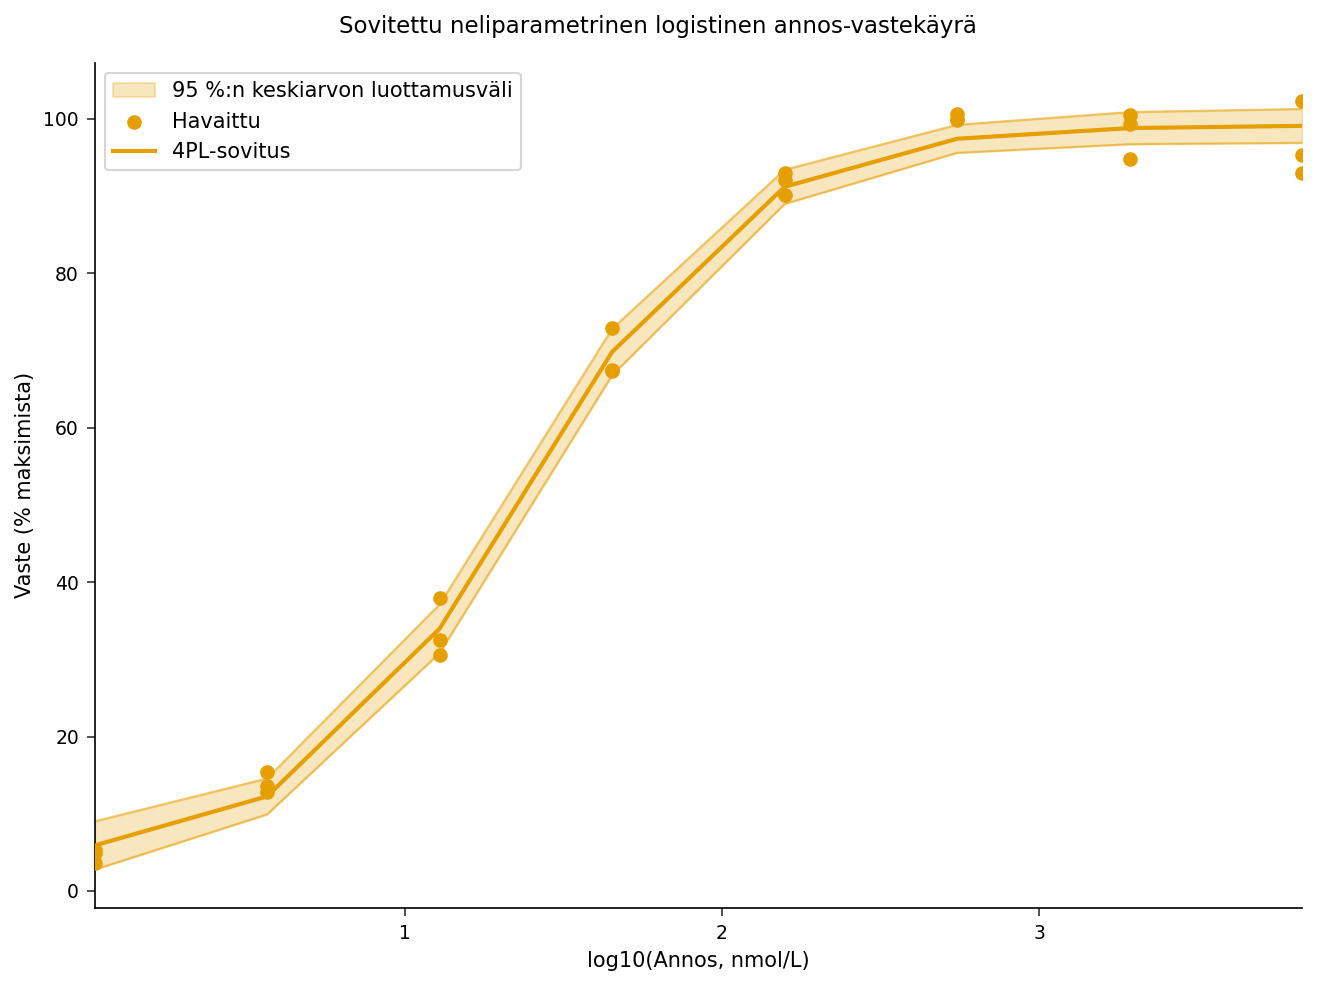

In [5]:
PROSEDUURI LAJITTELE TIEDOT=fit4pl;
    MUKAAN logdose;
SUORITA;

PROSEDUURI SGPLOT TIEDOT=fit4pl;
    BAND   x=logdose LOWER=lcl UPPER=ucl /
           TRANSPARENCY=0.5 legendlabel='95 %:n keskiarvon luottamusväli';
    SCATTER x=logdose y=response /
           MARKERATTRS=(SYMBOL=circlefilled)
           legendlabel='Havaittu';
    SERIES  x=logdose y=pred /
           LINEATTRS=(thickness=2)
           legendlabel='4PL-sovitus';
    XAXIS LABEL='log10(Annos, nmol/L)';
    YAXIS LABEL='Vaste (% maksimista)';
    OTSIKKO 'Sovitettu neliparametrinen logistinen annos-vastekäyrä';
SUORITA;
OTSIKKO;

## Tulosten tulkinta

`PROC NLIN` konvergoi estimaatteihin, jotka ovat lähellä tunnettuja generoivia arvoja: alempi asymptootti lähellä arvoa **5**, ylempi asymptootti lähellä arvoa **100**, **EC50 (C)** lähellä arvoa **25 nmol/L** ja **Hillin kulmakerroin (B)** lähellä arvoa **1.2**. Näiden parametrien palauttaminen kohinaisista kolmoistoistotiedoista vahvistaa, että malli on identifioituva eivätkä rajat sitoneet optimissa.

**EC50** on keskeisin potenssin mittari: pienemmät arvot osoittavat tehokkaampaa yhdistettä, ja suhteellisen potenssin määrityksessä testierän EC50:tä verrataan vertailustandardiin. **Hillin kulmakerroin** kuvaa kooperatiivisuutta ja määrityksen jyrkkyyttä — lähellä arvoa 1 oleva kulmakerroin on yhdenmukainen yksinkertaisen yhden sitoutumispaikan mallin kanssa. **Asymptootit** määrittävät määrityksen dynaamisen alueen; vakaa, hyvin erottuva pohja ja huippu ovat validoitavan biomäärityksen edellytyksiä.

Sovituskuvio näyttää sigmoidin kulkevan havaittujen pisteiden pilven läpi tiukalla 95 %:n keskiarvon luottamusvyöhykkeellä vasteellisen alueen läpi, eikä residuaalidiagnostiikan pitäisi näyttää systemaattista kaarevuutta — mikä on osoitus siitä, että 4PL-muoto on riittävä. Käytännössä laajentaisit tätä työnkulkua `PROFILE`-uskottavuusväleillä EC50:lle, `BOOTSTRAP`-lauseella jakaumasta riippumattomaan parametri-inferenssiin tai rinnakkaissuoraviiva-analyysillä, joka vertaa testi- ja vertailueriä suhteellisen potenssin estimoimiseksi.